# XAI Pipeline Latency Analysis — Figures (Interactive View)

Displays the dissertation figures and summary statistics for interactive inspection.

**This notebook computes nothing and saves nothing.** `analysis/mann_whitney.py` is the
single source of truth for every reported number and figure; this notebook only renders
what that script produced. Earlier versions re-implemented the plotting here, which let
the two drift apart — displaying the artefacts instead makes that impossible.

To refresh everything below:

```bash
python analysis/mann_whitney.py aws_results
```

**Dataset:** `aws_results/` — 3 architectures x 5 concurrency levels (1, 5, 10, 25, 50 users)
x 5 repeat runs x 60 s = 75 runs. In-VPC load generator, private IP, uniform 30 s client SLA.

**Arms:** No XAI (control) | Synchronous XAI (inline SHAP) | Asynchronous XAI (Tier-1 inline,
Tier-2 via Redis + background workers).

In [1]:
from pathlib import Path
import pandas as pd
from IPython.display import display, Image, Markdown

# Works whether the kernel starts in the repo root or in notebooks/
ROOT = Path.cwd()
while not (ROOT / "aws_results").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent

RESULTS = ROOT / "aws_results"
PLOTS = RESULTS / "plots"
print("Results:", RESULTS)

Results: C:\Users\harsh\NCI\Sem2\Practicum\xai-throughput-optimizer\aws_results


## Benchmark summary

`p95 mean` and `p95 median` are both reported because the asynchronous arm is **bimodal**
at 25-50 users: most runs sit near the median and a minority stall completely, so the mean
is dominated by the outlier. The hypothesis tests use medians.

In [2]:
summary = pd.read_csv(RESULTS / "summary_table.csv")
display(summary)

,Architecture,Concurrent Users,p50 (ms),p95 mean (ms),p95 median (ms),p95 min (ms),p95 max (ms),p99 (ms),Throughput (req/s),Failure Rate (%),Request Count,Repeats
0,No XAI,1,10,20,18,15,32,25,0.53,0.0,153,5
1,No XAI,5,10,24,22,21,29,46,2.55,0.0,750,5
2,No XAI,10,10,22,22,18,26,41,5.06,0.0,1493,5
3,No XAI,25,10,28,29,23,31,50,12.22,0.0,3604,5
4,No XAI,50,11,33,32,28,38,63,23.27,0.0,6870,5
5,Synch XAI,1,226,894,830,700,1300,1138,0.44,0.0,128,5
6,Synch XAI,5,394,2020,1900,1700,2400,2540,1.99,0.0,586,5
7,Synch XAI,10,1078,4380,4500,3900,4900,6340,2.86,0.0,841,5
8,Synch XAI,25,4800,16600,18000,14000,19000,21400,2.72,0.0,799,5
9,Synch XAI,50,10360,30000,30000,30000,30000,30000,2.69,10.7,782,5


## Per-run distribution behind each cell

The single most important sanity check: a cell reported as one number is really five runs.

In [3]:
report = (RESULTS / "mann_whitney_report.txt").read_text(encoding="utf-8")
start = report.find("Per-run p95 values")
end = report.find("Right-censoring audit")
print(report[start:end].strip() if start != -1 else "Section not found - re-run the script.")

Per-run p95 values (run-level distribution behind each cell) 
  arch        users      mean    median   ratio   individual runs
  No XAI          1        20        18    1.1x   [16, 15, 32, 19, 18]
  No XAI          5        24        22    1.1x   [21, 29, 26, 22, 21]
  No XAI         10        22        22    1.0x   [24, 22, 18, 19, 26]
  No XAI         25        28        29    1.0x   [23, 29, 26, 31, 30]
  No XAI         50        33        32    1.0x   [28, 29, 32, 36, 38]
  Synch XAI       1       894       830    1.1x   [830, 880, 1300, 700, 760]
  Synch XAI       5     2,020     1,900    1.1x   [2400, 2200, 1900, 1700, 1900]
  Synch XAI      10     4,380     4,500    1.0x   [4500, 4000, 4600, 3900, 4900]
  Synch XAI      25    16,600    18,000    0.9x   [18000, 14000, 14000, 19000, 18000]
  Synch XAI      50    30,000    30,000    1.0x   [30000, 30000, 30000, 30000, 30000]
  Asynch XAI      1        28        26    1.1x   [42, 29, 26, 19, 23]
  Asynch XAI      5        52      

## Figures

### fig1_p95_latency.png
p95 tail latency vs concurrency (median of 5 runs, min-max whiskers)

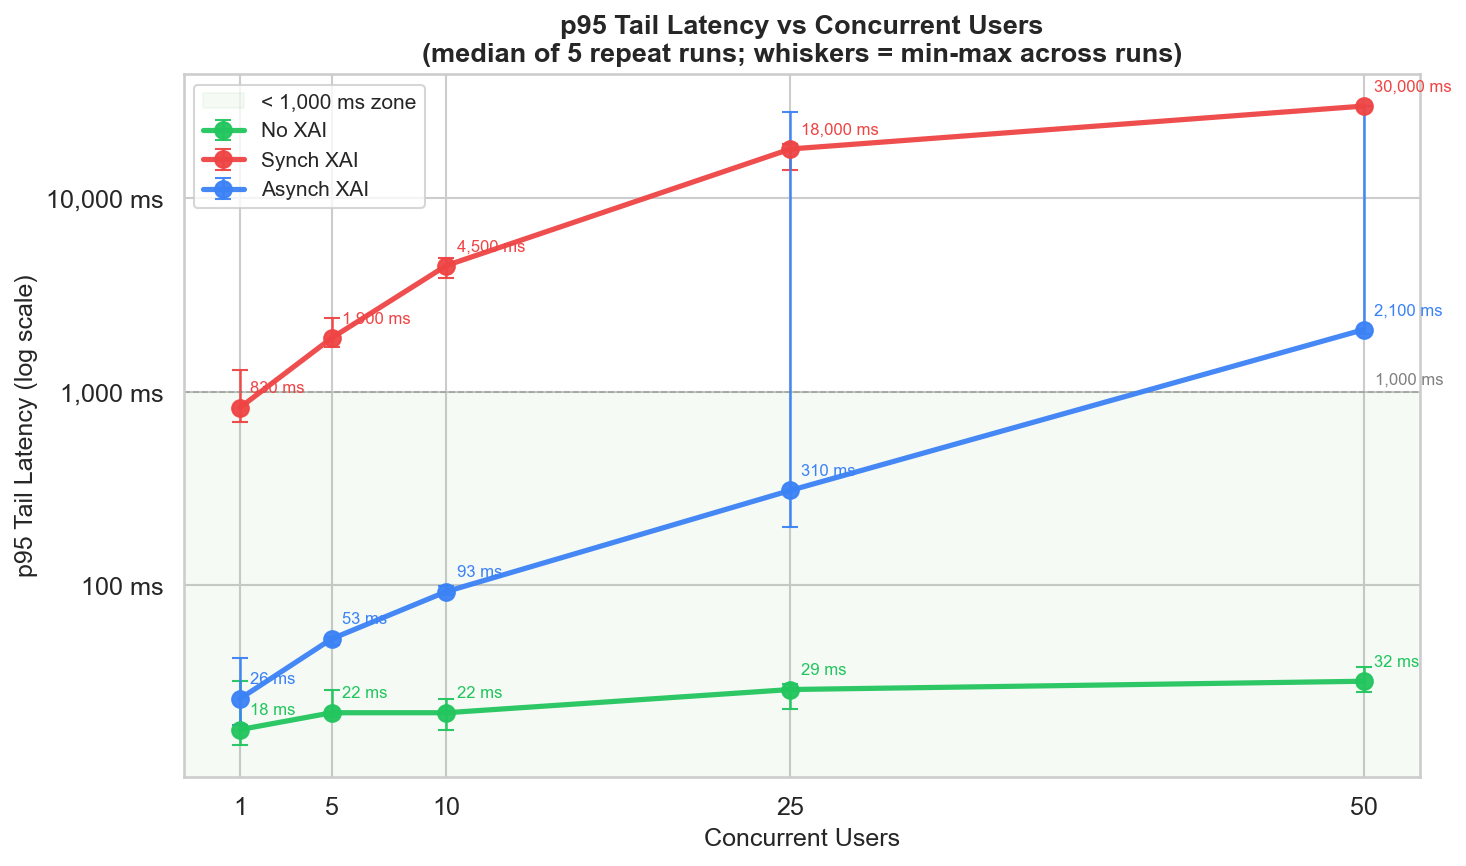

### fig2_percentile_comparison.png
p50 / p95 / p99 across all three architectures

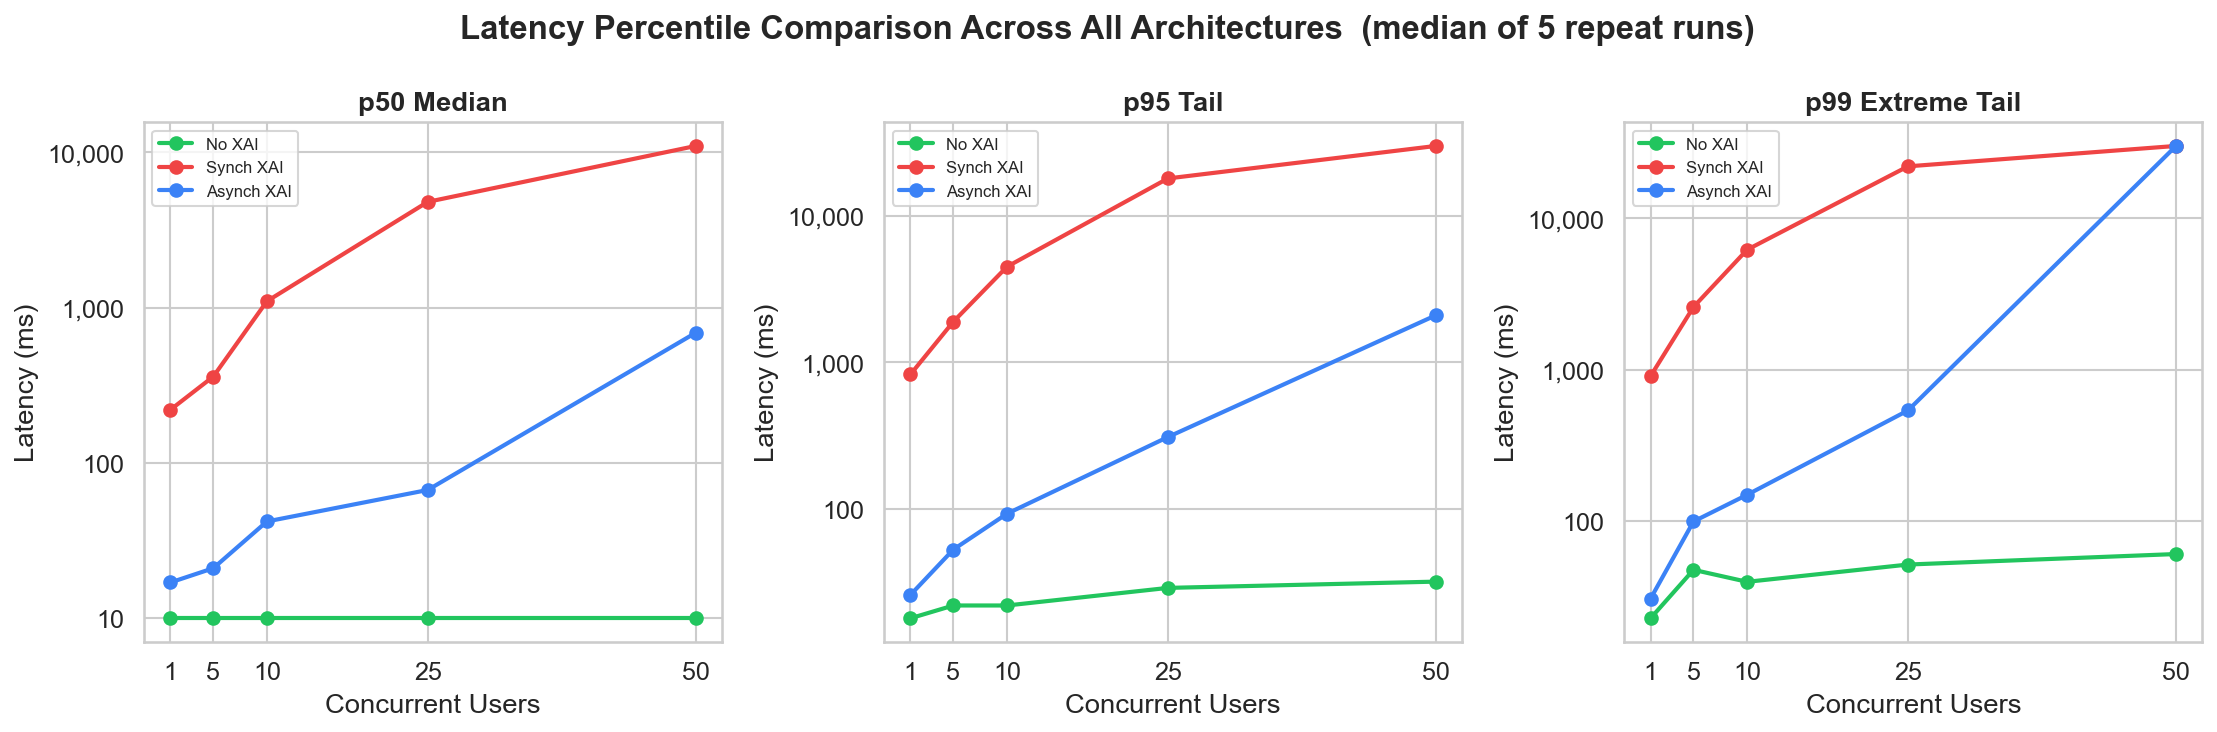

### fig3_throughput.png
Throughput vs concurrency

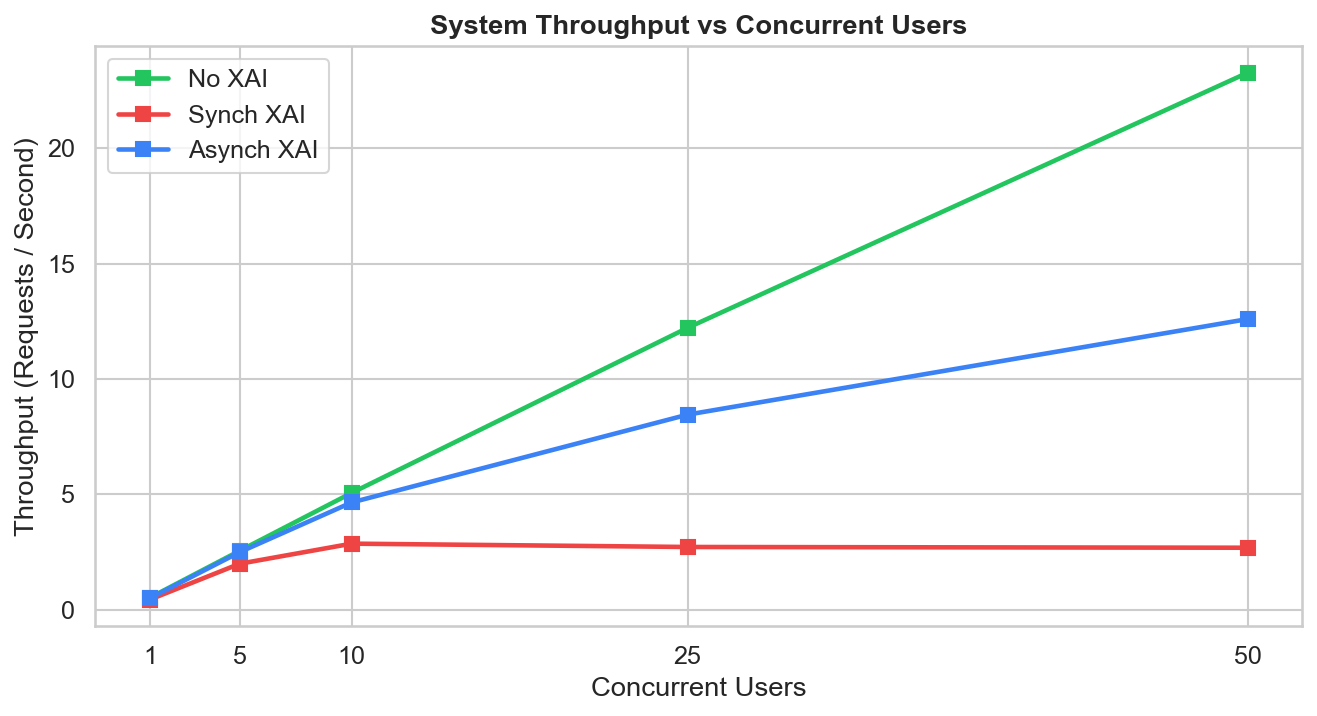

### fig4_failure_rate.png
Request failure rate under the uniform 30 s SLA

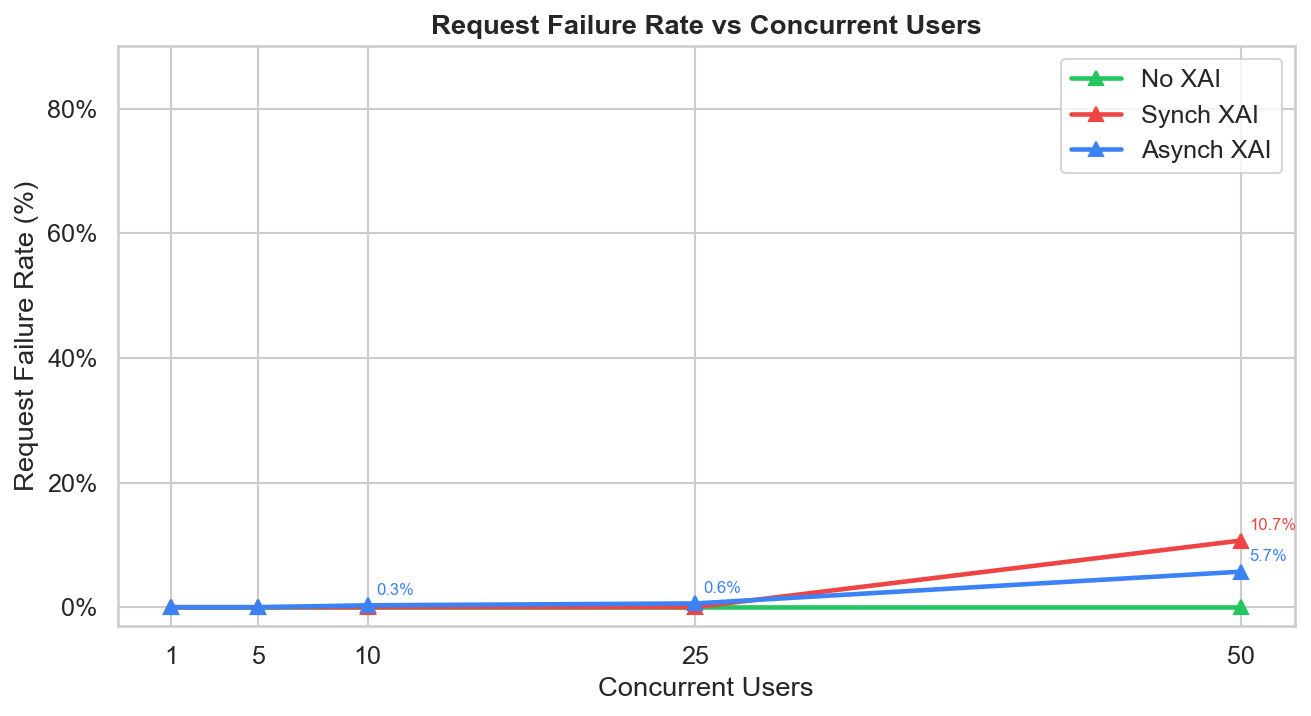

### fig5_boxplots.png
Per-run p95 distributions underlying the pooled tests

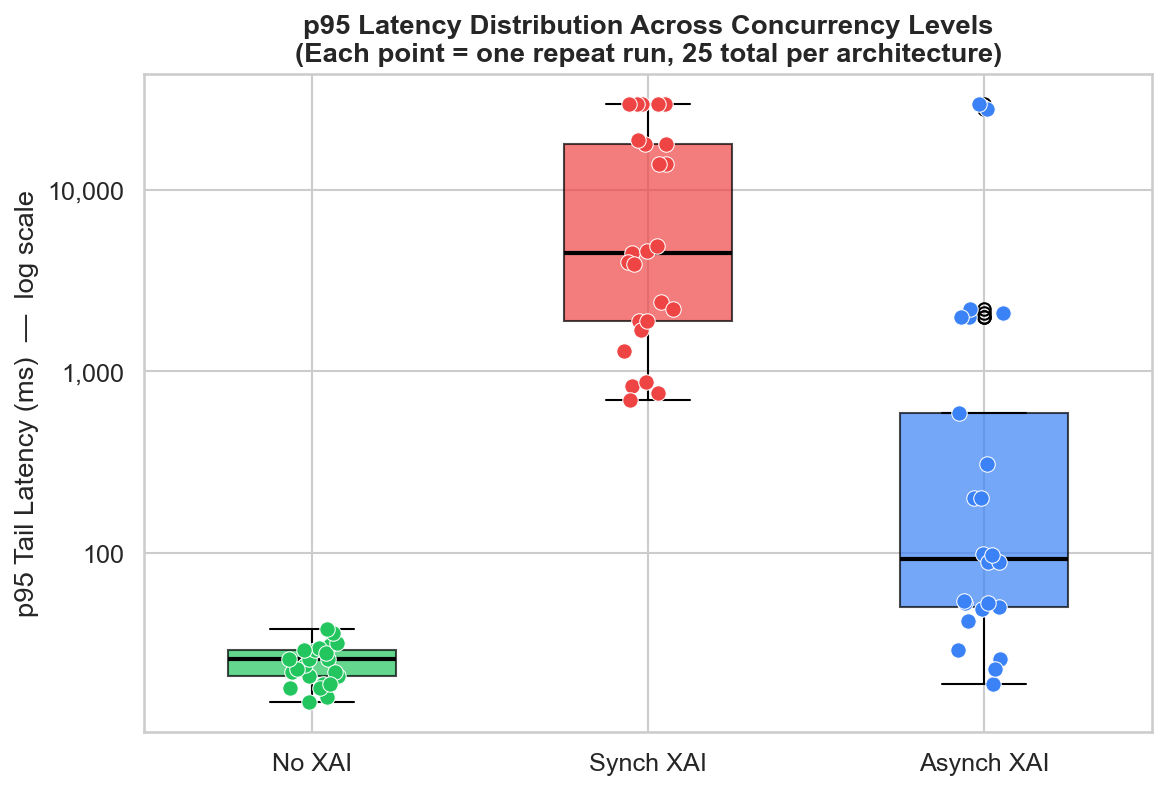

### fig6_tier2_envelope.png
Tier-2 completion envelope - relocated cost, not eliminated

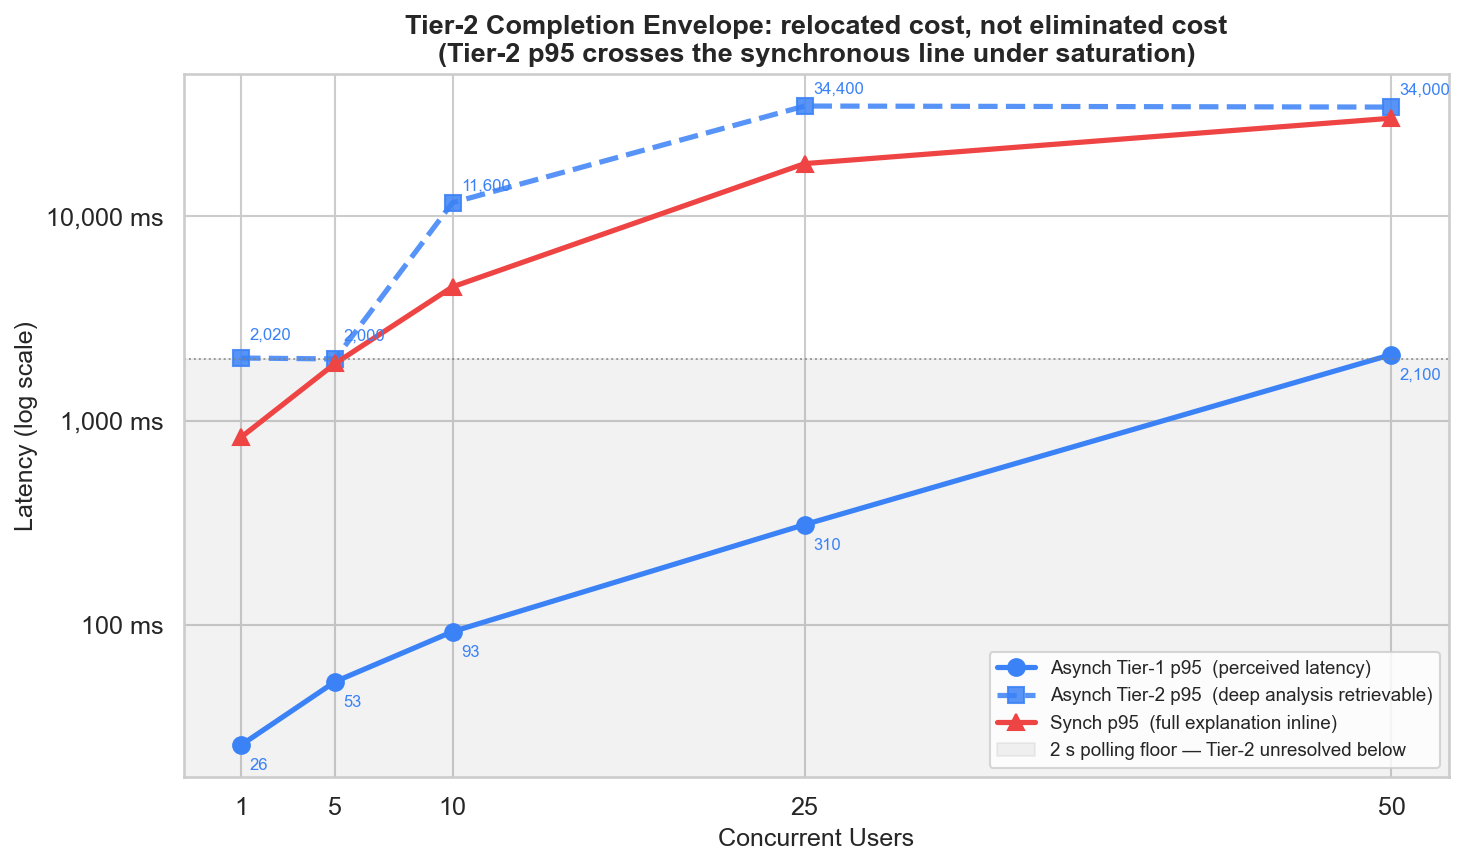

### fig7_async_speedup.png
Synchronous vs asynchronous p95, with speedup factors

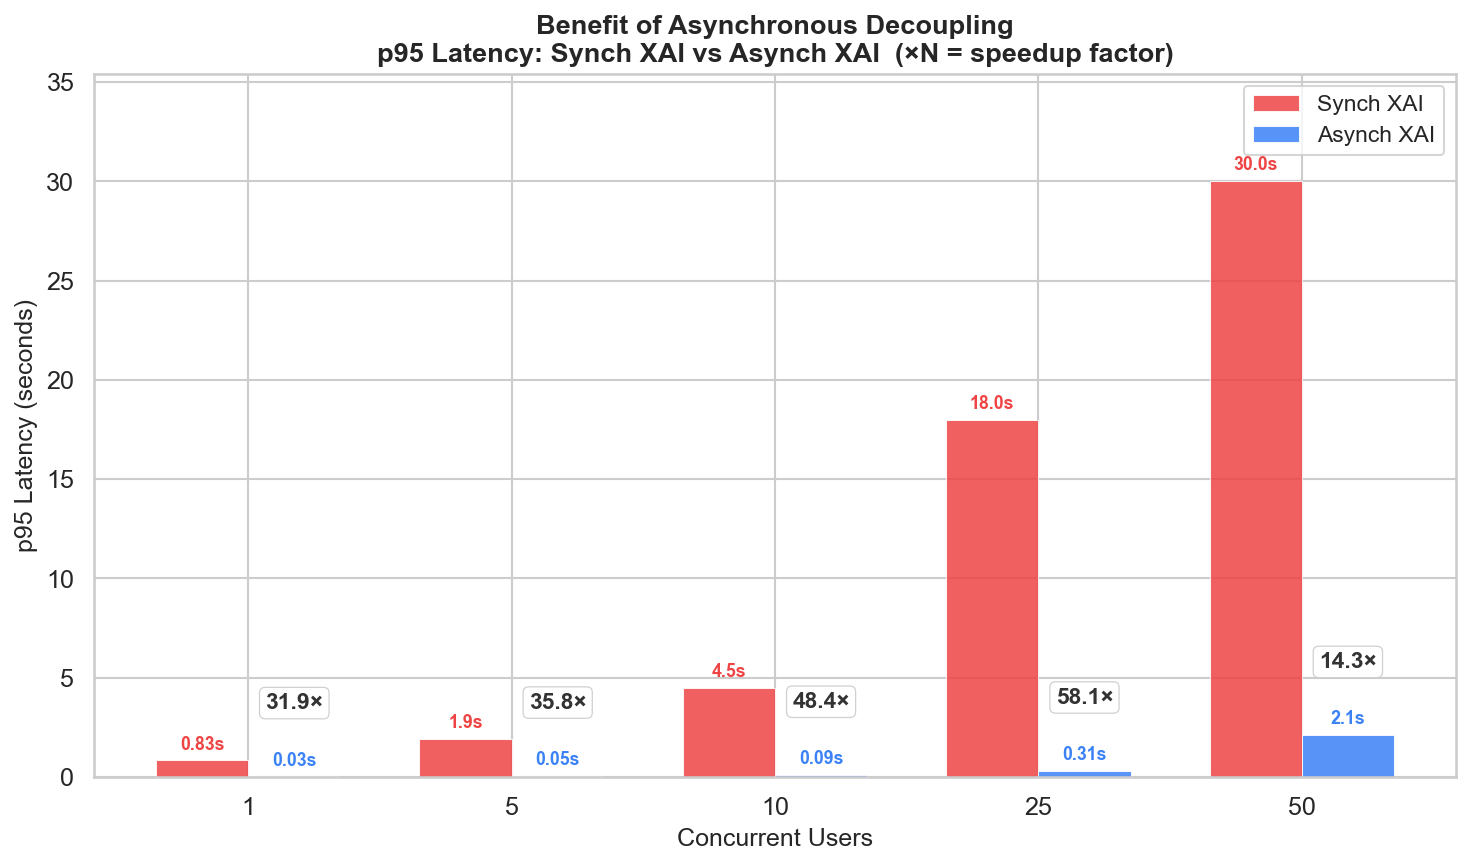

In [4]:
CAPTIONS = {
    "fig1_p95_latency.png":          "p95 tail latency vs concurrency (median of 5 runs, min-max whiskers)",
    "fig2_percentile_comparison.png": "p50 / p95 / p99 across all three architectures",
    "fig3_throughput.png":            "Throughput vs concurrency",
    "fig4_failure_rate.png":          "Request failure rate under the uniform 30 s SLA",
    "fig5_boxplots.png":              "Per-run p95 distributions underlying the pooled tests",
    "fig6_tier2_envelope.png":        "Tier-2 completion envelope - relocated cost, not eliminated",
    "fig7_async_speedup.png":         "Synchronous vs asynchronous p95, with speedup factors",
}

for name in sorted(PLOTS.glob("*.png")):
    display(Markdown(f"### {name.name}\n{CAPTIONS.get(name.name, '')}"))
    display(Image(filename=str(name)))

## Hypothesis tests

H1 and H2 use one-sided Mann-Whitney U on per-run p95s. H3 uses **TOST equivalence** with a
pre-registered 1.5x margin - a non-significant two-sided test is not evidence of equivalence.

In [5]:
start = report.find("HYPOTHESIS TESTS")
end = report.find("PER-CONCURRENCY-LEVEL ANALYSIS")
print(report[start:end].strip() if start != -1 else "Section not found - re-run the script.")

HYPOTHESIS TESTS

  Research Narrative
  ──────────────────
  The three tests form a sequential chain of evidence designed to answer
  the central research question: Can asynchronous decoupling make XAI
  computationally transparent to the user under concurrent load?

  Step 1 establishes that the problem is real.
  Step 2 validates that the proposed solution addresses it.
  Step 3 tests whether the solution achieves the ideal outcome.


  Step 1  (Establish the problem): Synchronous XAI inflates tail latency beyond the no-XAI baseline
  Research question : Is the latency problem caused by XAI, or by the API infrastructure?
  Test              : Mann-Whitney U [greater],  Synch XAI  vs  No XAI
  U statistic       : 625.0
  p-value           : 0.0000   (< 0.05 — significant)
  Effect size       : r = 1.0  (large effect)
  Median Synch XAI         :    4,500 ms
  Median No XAI            :       26 ms
  Verdict           : SUPPORTED  ✓

  Step 2  (Validate the solution): Async pipeline s

In [6]:
start = report.find("INTERPRETATION")
print(report[start:].strip() if start != -1 else "Section not found - re-run the script.")

INTERPRETATION

  Step 1 — Problem established:
  CONFIRMED
  Synch XAI inflates median p95 TAIL latency 173x vs No XAI
  (4,500 ms vs 26 ms).
  Median RESPONSE latency (p50) ratio is 110x (1,100 ms vs 10 ms).
  These are different statistics — quote the one the surrounding text names.
  The bottleneck is XAI computation, not API infrastructure.
  p = 0.0000, r = 1.0 (large effect).

  Step 2 — Solution validated:
  CONFIRMED
  Asynch XAI reduces median p95 from 4,500 ms (Synch XAI) to
  93 ms — a 98% reduction.
  Asynchronous decoupling via Redis/Celery is a statistically validated
  architectural fix. p = 0.0000, r = 0.76 (large effect).

  Step 3 — Ideal outcome (TOST equivalence, pre-registered margin 1.5x):
  NOT FULLY ACHIEVED (scope limitation)
  Equivalence to the no-XAI floor could not be demonstrated at any tested margin up to 3.0x. Asynch XAI still reduces tail latency by ~98% vs Synch XAI (Step 2 confirmed). Two-sided MW p = 0.0000 (descriptive). Future work: precompute or 